# Zaks et al. 2012 — strict-source MxlPy port and figure reruns

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mxlmodels import get_zaks2012
from mxlpy import Model, Simulator, make_protocol

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [3]:
from scipy.io import loadmat

data = loadmat("../src/mxlmodels/data/zaks2012/Code/simulations/sampleSim.mat",squeeze_me=True, struct_as_record=False)['npqsim']

In [4]:
def compare_dicts(d1, d2):
    keys1 = set(d1)
    keys2 = set(d2)

    only_in_d1 = keys1 - keys2
    only_in_d2 = keys2 - keys1
    union = keys1 & keys2

    different_values = {
        key: (d1[key], d2[key])
        for key in union
        if d1[key] != d2[key]
    }

    return {
        "only_in_d1": only_in_d1,
        "only_in_d2": only_in_d2,
        "different_values": different_values,
    }

d1 = {i: get_zaks2012()._parameters[i].value for i in get_zaks2012()._parameters.keys()}
d2 = {name: getattr(data.params, name) for name in data.params._fieldnames}
compare_dicts(d1, d2)



{'only_in_d1': {'ATPperProton',
  'F_PsbS',
  'LightIntensity',
  'P680neut',
  'qtrigg1',
  'qtrigg2',
  'qtrigg3'},
 'only_in_d2': {'LumenClStart', 'LumenKStart', 'LumenMgStart', 'Pkea'},
 'different_values': {}}

In [27]:
data.simparams.varnames.PSII_RC

array(['RC_a', 'RC_b', 'P680plus', 'PheAnion', 'QAox', 'LumenProtons'], dtype=object)

In [ ]:
protocol = pd.DataFrame({
    "Timedelta": data.timevalues[1:],
    "LightIntensity": data.LightIntensity[1:],
})#.set_index("Timedelta")

protocol["distance"]= protocol["Timedelta"].diff().fillna(0)
protocol

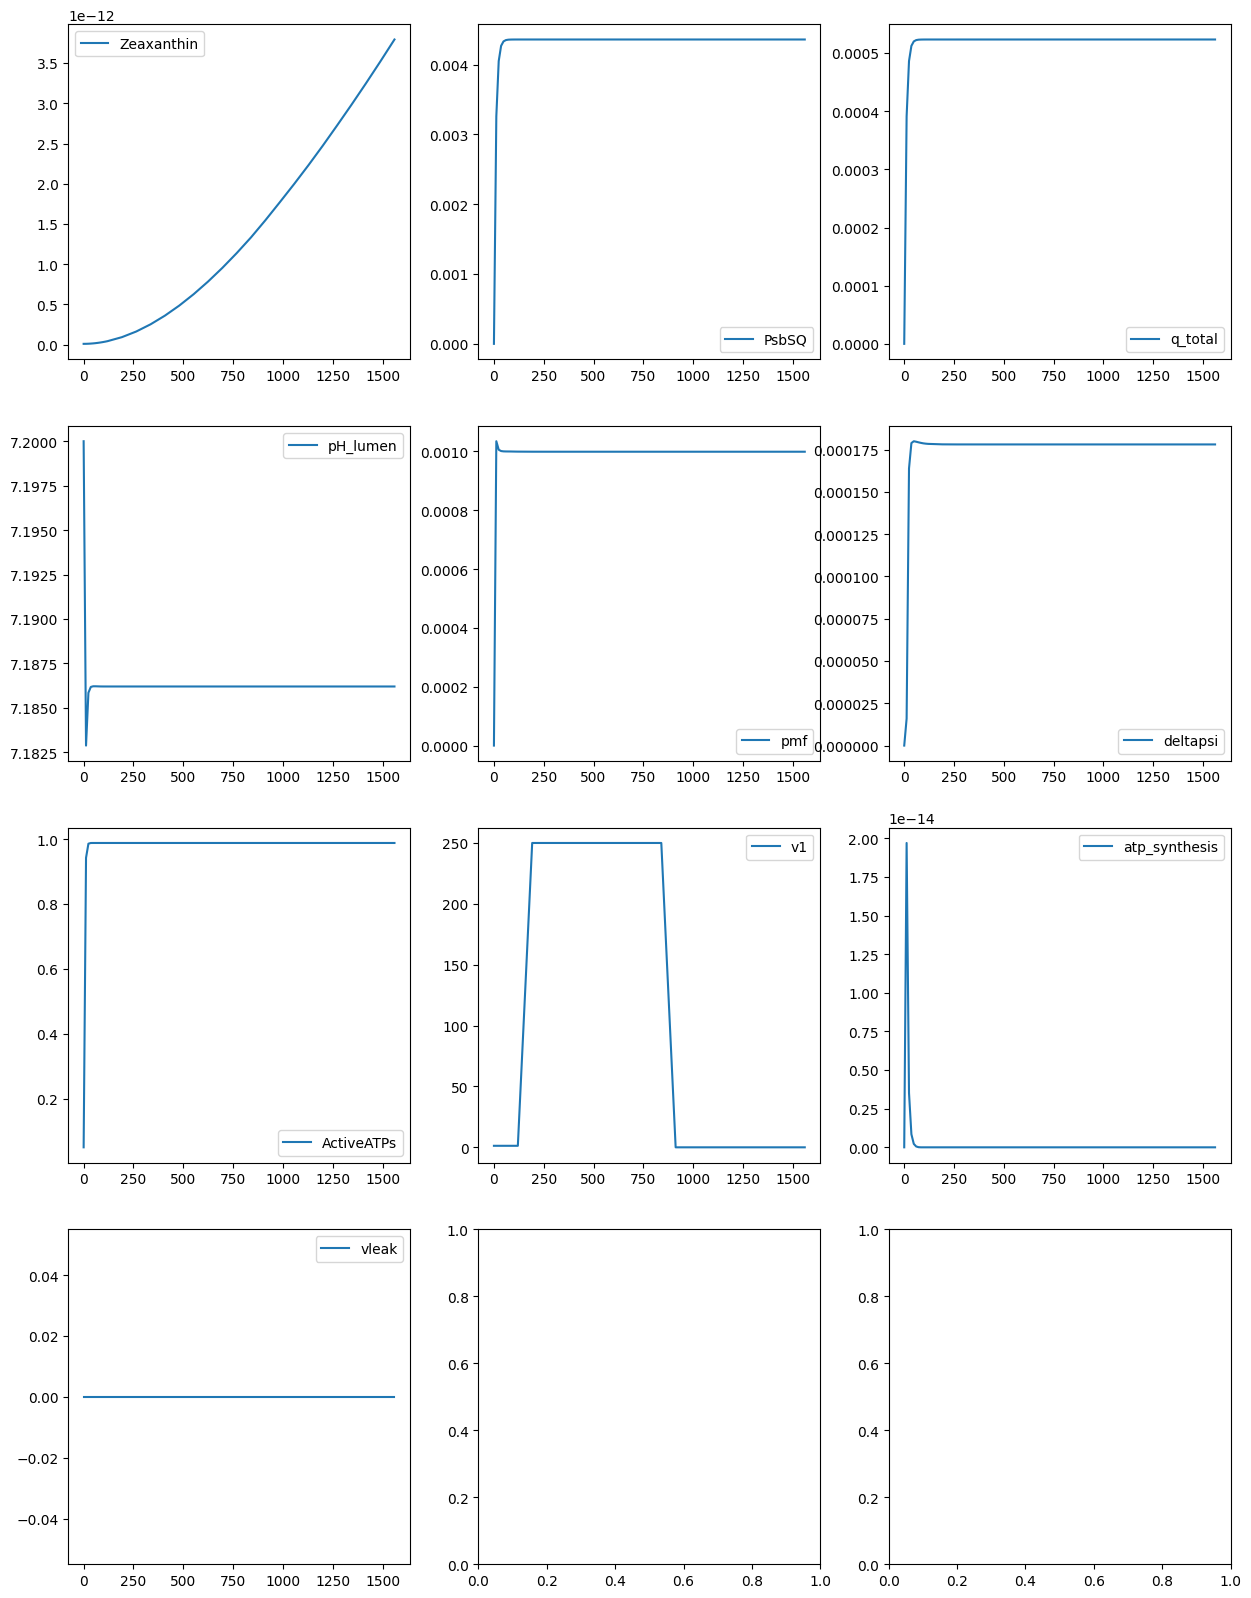

In [49]:
protocol = make_protocol([
        (120, {"LightIntensity": 5}),
        (720, {"LightIntensity": 1000.0}),
        (720, {"LightIntensity": 0}),
    ])

# protocol = pd.DataFrame({
#     "time": data.timevalues[1:],
#     "LightIntensity": data.LightIntensity[1:],
# })

res = Simulator(get_zaks2012(),
                # integrator=Scipy(rhs=get_zaks2012().get_right_hand_side(), y0=get_zaks2012().get_initial_conditions(),atol=1e-8, rtol=1e-8),
                ).simulate_protocol(protocol, time_points_per_step=10).get_result().unwrap_or_err().get_combined()


name = ["Zeaxanthin", "PsbSQ", "q_total", 
        "pH_lumen", "pmf", "deltapsi","ActiveATPs", "v1", "atp_synthesis", "vleak"]#get_zaks2012().get_readout_names()

ncol = 3
nrow = int(len(name)/ncol) + 1
idx = res.index
fig, axs = plt.subplots(ncols=ncol, nrows=nrow, figsize = (ncol*5, nrow*5))
axx = axs.flatten()
for var, ax in zip(name, axs.flatten()):
    ax.plot(idx, res[var], label = var)
    ax.legend()

plt.show()

In [33]:
protocol

,LightIntensity
Timedelta,
0 days 00:12:00,10.0
0 days 00:24:00,0.0


In [21]:
res.tail()

,PSIIChlEx,P680ex,P680plus,PheAnion,QAox,LumenProtons,QBneut,QBred1,QBred2,PQ,PQH2,PCr,P700ox,P700r,Fdxr,Fdxox,TotalLEF,ATP,ActiveATPs,LumenMg,LumenCl,LumenK,Antheraxanthin,Zeaxanthin,PsbSQ,pH_lumen,total_charge_lumen,deltapsi,deltapH,pmf,deltamuCl,deltamuMg,deltamuK,efield_slowdown_r,efield_slowdown_q,Violaxanthin,PsbS_unprot,active_vde,active_psbs,deact_psbs,q_total,QAred,Pheneut,PQfrac,PQH2frac,QBempty,frac_active_cyt,frac_pq_red,frac_active_pc,r_cyt_b6f,light,kF_obs,kqE_obs,kPC_obs,kPCRCC_obs,kC_obs,allrates,allratesRCC,fluorescenceyield,fluorescenceyieldRCC,qE_model,phi_npq,V_to_A,A_to_Z,Z_to_A,A_to_V,PsbS_prot,PsbS_deprot,v1,v2,v3,v4,v5,v7,v8,v9,v12,v13,v14,v15,v16,v17,v18,r_q2,r_q3,r_q4,r_q5,r_q6,r_q7,r_q8,cyt_b6f,psi_1,psi_2,atp_synthesis,atps_activate,atps_inactivate,flux_Mg,flux_Cl,flux_K
9.595960e-07,1.655364e-30,2.689205e-33,1.273291e-17,6.355504e-28,1.0,9.673672e-12,1.0,1.002076e-07,1.077574e-07,8.999,0.001,0.2,9.988494e-15,1.0,1.000000e-14,1.0,1.000000e-14,2.0,0.05,0.01,0.01,0.01,1.242186e-14,1.000000e-14,3.805172e-10,7.2,0.02,-6.972062e-09,-6.775442e-10,-7.012392e-09,6.972062e-09,-1.394412e-08,-6.972062e-09,1.0,1.0,1.0,1.0,6.309573e-08,0.003965,0.996035,4.566206e-11,9.985966e-08,1.0,0.8999,0.0001,9.236313e-08,0.979535,0.000111,0.933333,0.010158,0.0,1.158755e-22,2.267621e-31,8.276822e-21,8.276822e-21,9.435577e-22,9.220379e-21,9.220380e-21,100.0,100.0,100.0,100.0,2.523829e-09,1.567532e-23,4.000000e-18,4.968743e-18,0.000397,3.790083e-11,0.0,2.267621e-31,1.158755e-22,1.053880e-38,8.276822e-22,8.276822e-21,2.689205e-23,2.689205e-25,8.067615e-21,2.685431e-30,1.906651e-18,3.819872e-10,4.046201e-36,3.814510e-23,4.687006e-49,0.000350,1.601072e-11,0.000035,0.000172,0.000042,0.000086,0.008,0.010158,1.198619e-11,0.0,-0.0,2.375000e-15,0.00015,2.427349e-10,-6.068373e-11,6.068373e-11
9.696970e-07,1.243360e-30,2.019959e-33,1.098867e-17,4.779659e-28,1.0,9.775394e-12,1.0,1.002098e-07,1.078391e-07,8.999,0.001,0.2,9.988373e-15,1.0,1.000000e-14,1.0,1.000000e-14,2.0,0.05,0.01,0.01,0.01,1.244735e-14,1.000000e-14,3.845225e-10,7.2,0.02,-6.964210e-09,-6.741532e-10,-7.004338e-09,6.964210e-09,-1.392842e-08,-6.964210e-09,1.0,1.0,1.0,1.0,6.309573e-08,0.003965,0.996035,4.614270e-11,9.985823e-08,1.0,0.8999,0.0001,9.228278e-08,0.979535,0.000111,0.933333,0.010158,0.0,8.703517e-23,1.721159e-31,6.216797e-21,6.216798e-21,7.087149e-22,6.925512e-21,6.925513e-21,100.0,100.0,100.0,100.0,2.523829e-09,1.570749e-23,4.000000e-18,4.978940e-18,0.000397,3.829978e-11,0.0,1.721159e-31,8.703517e-23,6.831435e-39,6.216798e-22,6.216797e-21,2.019959e-23,2.019959e-25,6.059878e-21,2.017096e-30,1.433898e-18,3.296602e-10,2.626105e-36,3.291927e-23,3.041963e-49,0.000350,1.601083e-11,0.000035,0.000173,0.000042,0.000086,0.008,0.010158,1.198605e-11,0.0,-0.0,2.375000e-15,0.00015,2.424615e-10,-6.061539e-11,6.061539e-11
9.797980e-07,8.313546e-31,1.350714e-33,9.244438e-18,3.203815e-28,1.0,9.877116e-12,1.0,1.002119e-07,1.079208e-07,8.999,0.001,0.2,9.988252e-15,1.0,1.000000e-14,1.0,1.000000e-14,2.0,0.05,0.01,0.01,0.01,1.247284e-14,1.000000e-14,3.885279e-10,7.2,0.02,-6.956358e-09,-6.707630e-10,-6.996284e-09,6.956358e-09,-1.391272e-08,-6.956358e-09,1.0,1.0,1.0,1.0,6.309573e-08,0.003965,0.996035,4.662334e-11,9.985680e-08,1.0,0.8999,0.0001,9.220242e-08,0.979535,0.000111,0.933333,0.010158,0.0,5.819483e-23,1.162816e-31,4.156773e-21,4.156773e-21,4.738721e-22,4.630645e-21,4.630645e-21,100.0,100.0,100.0,100.0,2.523829e-09,1.573966e-23,4.000000e-18,4.989137e-18,0.000397,3.869872e-11,0.0,1.162816e-31,5.819483e-23,3.842703e-39,4.156773e-22,4.156773e-21,1.350714e-23,1.350714e-25,4.052141e-21,1.348780e-30,9.611444e-19,2.773331e-10,1.480873e-36,2.769360e-23,1.715353e-49,0.000349,1.601095e-11,0.000035,0.000173,0.000041,0.000086,0.008,0.010158,1.198590e-11,0.0,-0.0,2.375000e-15,0.00015,2.421882e-10,-6.054704e-11,6.054704e-11
9.898990e-07,4.193497e-31,6.814680e-34,7.500204e-18,1.627970e-28,1.0,9.978838e-12,1.0,1.002141e-07,1.080025e-07,8.999,0.001,0.2,9.988131e-15,1.0,1.000000e-14,1.0,1.000000e-14,

In [14]:
int(17/3)

5

In [ ]:
def run_pam_condition(actinic: float, model: Model, t_end: float = 1100.0, dt: float = 1.0):
    s = Simulator(model)
    t_eval = np.arange(0.0, t_end + dt, dt)
    lf = pam_light_fn(actinic=actinic, pulse=2000.0, measuring=200.0, t_end=t_end)
    sol = s.simulate_protocol(lf).get_result().unwrap_or_err().get_combined()
    col_idx = model.get_arg_names(include_derived_parameters=True,
                                  include_variables=True, 
                                  include_derived_variables= True,
                                  include_time=False,
                                  include_parameters=False,
                                  include_readouts=True,
                                  include_reactions= False,
                                  include_surrogate_fluxes=False,
                                  include_surrogate_variables=False)
    df = pd.DataFrame(sol.y.T, columns=col_idx, index=sol.t)
    light_values = np.array([lf(t) for t in sol.t])
    obs = chlorophyll_observables(df, params, light_values=light_values, quenchmodel=qtype)
    return df.join(obs), light_values


def extract_pulse_npq(out: pd.DataFrame, light_values: np.ndarray, pulse_intensity: float = 2000.0):
    pulse = light_values >= pulse_intensity
    # group consecutive pulse samples
    idx = np.where(pulse)[0]
    if len(idx) == 0:
        return pd.DataFrame(columns=["time", "Fmprime", "NPQ"])
    groups = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    times, fmps = [], []
    for g in groups:
        yy = out["fluorescenceyieldRCC"].iloc[g]
        times.append(out.index[g[0]])
        fmps.append(float(yy.max()))
    fm = fmps[0]
    return pd.DataFrame({"time": times, "Fmprime": fmps, "NPQ": [(fm - x) / x for x in fmps]})


/home/huy/Huy/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/home/huy/Huy/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/home/huy/Huy/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/home/huy/Huy/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE
/tmp/ipykernel_421543/3286398503.py:152: RuntimeWarning: overflow encountered in scalar multiply
  r_psi_2 = light * p["PSIcrossSection"] * p["kETP700Fdx"] * p700_r * fdx_ox
/home/huy/Huy/mxl-models/.ven

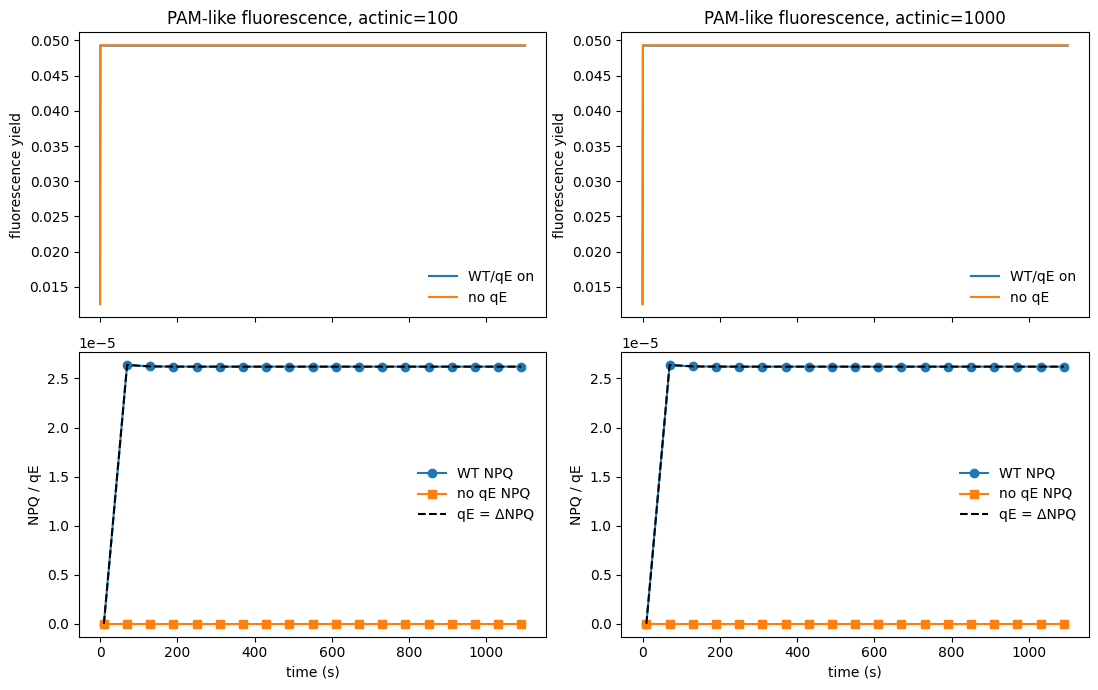

In [ ]:

# Reproduce main-paper style qE / PAM simulation panels for actinic light 100 and 1000
# The paper plots measured and simulated PAM traces and qE = NPQ(WT) - NPQ(npq4).

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
summary = {}
for j, actinic in enumerate([100.0, 1000.0]):
    wt, light_wt = run_pam_condition(actinic, qtype=1)
    no_qe, light_no = run_pam_condition(actinic, qtype=0)
    wt_npq = extract_pulse_npq(wt, light_wt)
    no_npq = extract_pulse_npq(no_qe, light_no)
    qE_pulse = wt_npq["NPQ"].to_numpy() - no_npq["NPQ"].to_numpy()
    summary[actinic] = {"wt": wt, "no_qe": no_qe, "wt_npq": wt_npq, "no_npq": no_npq, "qE_pulse": qE_pulse}

    ax = axes[0, j]
    ax.plot(wt.index, wt["fluorescenceyield"], label="WT/qE on")
    ax.plot(no_qe.index, no_qe["fluorescenceyield"], label="no qE")
    ax.set_title(f"PAM-like fluorescence, actinic={actinic:g}")
    ax.set_ylabel("fluorescence yield")
    ax.legend(frameon=False)

    ax = axes[1, j]
    ax.plot(wt_npq["time"], wt_npq["NPQ"], "o-", label="WT NPQ")
    ax.plot(no_npq["time"], no_npq["NPQ"], "s-", label="no qE NPQ")
    ax.plot(wt_npq["time"], qE_pulse, "k--", label="qE = ΔNPQ")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("NPQ / qE")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()


/home/huy/Huy/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/common.py:357: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/home/huy/Huy/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/common.py:326: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/home/huy/Huy/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/common.py:356: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/tmp/ipykernel_421543/3286398503.py:152: RuntimeWarning: overflow encountered in scalar multiply
  r_psi_2 = light * p["PSIcrossSection"] * p["kETP700Fdx"] * p700_r * fdx_ox
/home/huy/Huy/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/common.py:378: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE


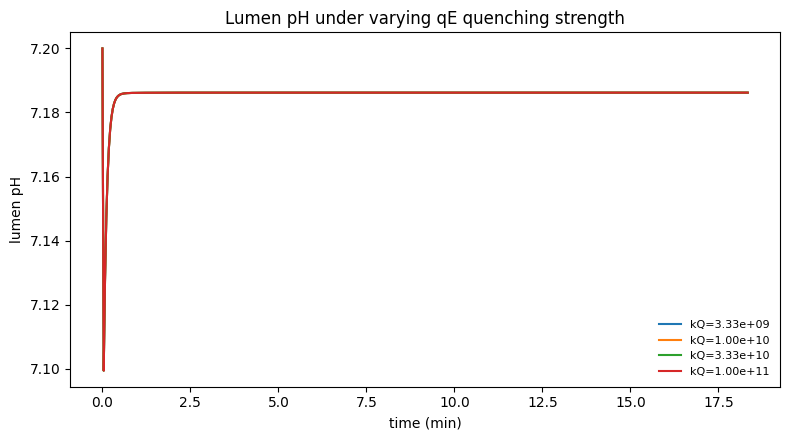

In [ ]:

# Main-paper-style parameter sweep: effect of qE strength kQ on lumen pH
# This corresponds to the paper's central claim that qE changes excitation dissipation but not lumen pH strongly.

kq_values = [1/300e-12, 1/100e-12, 1/30e-12, 1/10e-12]
t_eval = np.linspace(0, 1100, 500)
fig, ax = plt.subplots(figsize=(8, 4.5))
for kq in kq_values:
    p2 = dict(params)
    p2["kQ"] = float(kq)
    lf = pam_light_fn(actinic=1000.0, pulse=2000.0, measuring=200.0, t_end=1100.0)
    sol = simulate_zaks(p2, lf, t_span=(0, 1100), t_eval=t_eval, quenchmodel=1, max_step=1.0)
    df = pd.DataFrame(sol.y.T, columns=STATE_NAMES, index=sol.t)
    obs = chlorophyll_observables(df, p2, light_values=np.array([lf(t) for t in sol.t]), quenchmodel=1)
    ax.plot(df.index / 60, obs["pHLumen"], label=f"kQ={kq:.2e}")
ax.set_xlabel("time (min)")
ax.set_ylabel("lumen pH")
ax.set_title("Lumen pH under varying qE quenching strength")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:

# Optional: save generated figures as files
# Uncomment after running the figure cells if needed.
# plt.savefig("zaks_reproduced_figure.png", dpi=300, bbox_inches="tight")


## Notes on fidelity

- This is an A-style strict reproduction port, not a cleaned-up biological model.
- The MxlPy layer wraps each state derivative as one reaction so that the original MATLAB module coupling is preserved.
- The PAM pulse helper files in the public MATLAB code are compressed/awkwardly published in the repository, so this notebook uses the agreed simplified protocol: actinic light = 100 or 1000, measuring light = 200, saturating pulses = 2000.
- After validating quantitative behaviour, the next step is to split the model into explicit module/reaction objects and remove the derivative-wrapper workaround.